In [14]:
pip install selenium pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 10.8 MB 5.7 MB/s eta 0:00:01
     |████████████████████████████████| 348 kB 21.7 MB/s eta 0:00:01
     |████████████████████████████████| 508 kB 21.6 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [17]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import time

# inicializa o navegador (pode usar Chrome, Firefox, Edge, etc.)
driver = webdriver.Chrome()

# abre a página
driver.get("https://books.toscrape.com/")

# aguarda carregar
time.sleep(2)

In [ ]:
# percorre TODAS as paginas clicando no botao "next" e extrai todos os livros
from selenium.common.exceptions import NoSuchElementException

estrelas_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}

livros = []
pagina = 1

while True:
    # cada livro da pagina esta em <article class="product_pod">
    artigos = driver.find_elements(By.CSS_SELECTOR, "article.product_pod")

    for art in artigos:
        link_titulo = art.find_element(By.CSS_SELECTOR, "h3 a")
        classes = art.find_element(By.CSS_SELECTOR, "p.star-rating").get_attribute("class")
        nota = [estrelas_map[c] for c in classes.split() if c in estrelas_map][0]

        livros.append({
            "titulo": link_titulo.get_attribute("title"),          # titulo completo
            "preco": art.find_element(By.CSS_SELECTOR, "p.price_color").text,
            "estrelas": nota,
            "disponibilidade": art.find_element(By.CSS_SELECTOR, "p.instock.availability").text,
            "pagina": pagina,
            "link": link_titulo.get_attribute("href"),
            "imagem": art.find_element(By.CSS_SELECTOR, "img.thumbnail").get_attribute("src"),
        })

    print(f"pagina {pagina} -> {len(artigos)} livros (total: {len(livros)})")

    # botao next: <li class="next"><a href="catalogue/page-2.html">next</a></li>
    try:
        proximo = driver.find_element(By.CSS_SELECTOR, "li.next a")
    except NoSuchElementException:
        break  # ultima pagina, nao existe mais o "next"

    proximo.click()
    pagina += 1
    time.sleep(1)

print("\nFIM ->", pagina, "paginas,", len(livros), "livros")
driver.quit()

pagina 1 -> 20 livros (total: 20)
pagina 2 -> 20 livros (total: 40)
pagina 3 -> 20 livros (total: 60)
pagina 4 -> 20 livros (total: 80)
pagina 5 -> 20 livros (total: 100)
pagina 6 -> 20 livros (total: 120)
pagina 7 -> 20 livros (total: 140)
pagina 8 -> 20 livros (total: 160)
pagina 9 -> 20 livros (total: 180)
pagina 10 -> 20 livros (total: 200)
pagina 11 -> 20 livros (total: 220)
pagina 12 -> 20 livros (total: 240)
pagina 13 -> 20 livros (total: 260)
pagina 14 -> 20 livros (total: 280)
pagina 15 -> 20 livros (total: 300)
pagina 16 -> 20 livros (total: 320)
pagina 17 -> 20 livros (total: 340)
pagina 18 -> 20 livros (total: 360)
pagina 19 -> 20 livros (total: 380)
pagina 20 -> 20 livros (total: 400)
pagina 21 -> 20 livros (total: 420)
pagina 22 -> 20 livros (total: 440)
pagina 23 -> 20 livros (total: 460)
pagina 24 -> 20 livros (total: 480)
pagina 25 -> 20 livros (total: 500)
pagina 26 -> 20 livros (total: 520)
pagina 27 -> 20 livros (total: 540)
pagina 28 -> 20 livros (total: 560)
pagin

In [19]:
import pandas as pd
from IPython.display import display

df = pd.DataFrame(livros)
df["preco_gbp"] = df["preco"].str.replace("£", "", regex=False).str.replace("Â", "", regex=False).astype(float)
df = df[["titulo", "preco_gbp", "estrelas", "disponibilidade", "pagina", "link", "imagem"]]
df.index = df.index + 1  # numera de 1 a 1000

# mostra TODAS as linhas aqui no notebook (a saida fica com barra de rolagem)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", 60)

print(df.shape)
display(df)

(1000, 7)


,titulo,preco_gbp,estrelas,disponibilidade,pagina,link,imagem
1,A Light in the Attic,51.77,3,In stock,1,https://books.toscrape.com/catalogue/a-light-in-the-atti...,https://books.toscrape.com/media/cache/2c/da/2cdad67c44b...
2,Tipping the Velvet,53.74,1,In stock,1,https://books.toscrape.com/catalogue/tipping-the-velvet_...,https://books.toscrape.com/media/cache/26/0c/260c6ae16bc...
3,Soumission,50.10,1,In stock,1,https://books.toscrape.com/catalogue/soumission_998/inde...,https://books.toscrape.com/media/cache/3e/ef/3eef99c9d9a...
4,Sharp Objects,47.82,4,In stock,1,https://books.toscrape.com/catalogue/sharp-objects_997/i...,https://books.toscrape.com/media/cache/32/51/3251cf3a341...
5,Sapiens: A Brief History of Humankind,54.23,5,In stock,1,https://books.toscrape.com/catalogue/sapiens-a-brief-his...,https://books.toscrape.com/media/cache/be/a5/bea5697f253...
6,The Requiem Red,22.65,1,In stock,1,https://books.toscrape.com/catalogue/the-requiem-red_995...,https://books.toscrape.com/media/cache/68/33/68339b4c9bc...
7,The Dirty Little Secrets of Getting Your Dream Job,33.34,4,In stock,1,https://books.toscrape.com/catalogue/the-dirty-little-se...,https://books.toscrape.com/media/cache/92/27/92274a95b7c...
8,The Coming Woman: A Novel Based on the Life of the Infam...,17.93,3,In stock,1,https://books.toscrape.com/catalogue/the-coming-woman-a-...,https://books.toscrape.com/media/cache/3d/54/3d54940e57e...
9,The Boys in the Boat: Nine Americans and Their Epic Ques...,22.60,4,In stock,1,https://books.toscrape.com/catalogue/the-boys-in-the-boa...,https://books.toscrape.com/media/cache/66/88/66883b91f68...
10,The Black Maria,52.15,1,In stock,1,https://books.toscrape.com/catalogue/the-black-maria_991...,https://books.toscrape.com/media/cache/58/46/5846057e280...


In [20]:
# mesma tabela, so que "bonita": capa, titulo clicavel e estrelas em ★
from IPython.display import HTML

def linha(i, r):
    return f"""<tr>
      <td style="text-align:right;color:#888">{i}</td>
      <td><img src="{r.imagem}" style="height:60px;border-radius:3px"></td>
      <td><a href="{r.link}" target="_blank">{r.titulo}</a></td>
      <td style="text-align:right;white-space:nowrap">£{r.preco_gbp:.2f}</td>
      <td style="color:#e8a33d;white-space:nowrap">{"★" * r.estrelas}{"☆" * (5 - r.estrelas)}</td>
      <td style="white-space:nowrap">{r.disponibilidade}</td>
      <td style="text-align:right">{r.pagina}</td>
    </tr>"""

linhas = "".join(linha(i, r) for i, r in zip(df.index, df.itertuples()))

HTML(f"""
<div style="max-height:600px;overflow:auto;border:1px solid #ddd">
  <table style="border-collapse:collapse;width:100%;font-size:13px;background:#fff;color:#222">
    <thead style="position:sticky;top:0;background:#f4f4f4;color:#222">
      <tr>
        <th>#</th><th>Capa</th><th style="text-align:left">Titulo</th>
        <th>Preco</th><th>Estrelas</th><th>Disponibilidade</th><th>Pag</th>
      </tr>
    </thead>
    <tbody>{linhas}</tbody>
  </table>
</div>
<p><b>{len(df)}</b> livros extraidos de <b>{df["pagina"].max()}</b> paginas</p>
""")

#,Capa,Titulo,Preco,Estrelas,Disponibilidade,Pag
1,,A Light in the Attic,£51.77,★★★☆☆,In stock,1
2,,Tipping the Velvet,£53.74,★☆☆☆☆,In stock,1
3,,Soumission,£50.10,★☆☆☆☆,In stock,1
4,,Sharp Objects,£47.82,★★★★☆,In stock,1
5,,Sapiens: A Brief History of Humankind,£54.23,★★★★★,In stock,1
6,,The Requiem Red,£22.65,★☆☆☆☆,In stock,1
7,,The Dirty Little Secrets of Getting Your Dream Job,£33.34,★★★★☆,In stock,1
8,,"The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull",£17.93,★★★☆☆,In stock,1
9,,The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics,£22.60,★★★★☆,In stock,1
10,,The Black Maria,£52.15,★☆☆☆☆,In stock,1


In [21]:
# resumo
print("total de livros:", len(df))
print("preco medio: £%.2f" % df["preco_gbp"].mean())
print("mais caro:", df.loc[df["preco_gbp"].idxmax(), "titulo"], "-> £%.2f" % df["preco_gbp"].max())
print("mais barato:", df.loc[df["preco_gbp"].idxmin(), "titulo"], "-> £%.2f" % df["preco_gbp"].min())
print(df["estrelas"].value_counts().sort_index())

df.to_csv("livros.csv", index=False, encoding="utf-8")
print("salvo em livros.csv")

total de livros: 1000
preco medio: £35.07
mais caro: The Perfect Play (Play by Play #1) -> £59.99
mais barato: An Abundance of Katherines -> £10.00
estrelas
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64
salvo em livros.csv


In [22]:
# a categoria NAO aparece na listagem principal - ela so existe no menu lateral.
# entao percorremos categoria por categoria para saber a que cada livro pertence.
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.common.exceptions import NoSuchElementException
import time

estrelas_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}

driver = webdriver.Chrome()
driver.get("https://books.toscrape.com/")
time.sleep(2)

# pega o nome + link de cada categoria do menu lateral (guardamos os hrefs antes de
# navegar, senao os elementos ficam "stale" ao trocar de pagina)
categorias = [
    (a.text.strip(), a.get_attribute("href"))
    for a in driver.find_elements(By.CSS_SELECTOR, "div.side_categories ul li ul li a")
]
print("categorias encontradas:", len(categorias))

livros_cat = []
for nome, url in categorias:
    driver.get(url)
    time.sleep(0.5)
    while True:
        for art in driver.find_elements(By.CSS_SELECTOR, "article.product_pod"):
            classes = art.find_element(By.CSS_SELECTOR, "p.star-rating").get_attribute("class")
            livros_cat.append({
                "categoria": nome,
                "titulo": art.find_element(By.CSS_SELECTOR, "h3 a").get_attribute("title"),
                "preco": art.find_element(By.CSS_SELECTOR, "p.price_color").text,
                "estrelas": [estrelas_map[c] for c in classes.split() if c in estrelas_map][0],
            })
        try:
            driver.find_element(By.CSS_SELECTOR, "li.next a").click()   # categoria com mais de uma pagina
        except NoSuchElementException:
            break
        time.sleep(0.5)
    print(f"{nome}: {len(livros_cat)} livros acumulados")

driver.quit()
print("\nTOTAL:", len(livros_cat), "livros em", len(categorias), "categorias")

categorias encontradas: 50
Travel: 11 livros acumulados
Mystery: 43 livros acumulados
Historical Fiction: 69 livros acumulados
Sequential Art: 144 livros acumulados
Classics: 163 livros acumulados
Philosophy: 174 livros acumulados
Romance: 209 livros acumulados
Womens Fiction: 226 livros acumulados
Fiction: 291 livros acumulados
Childrens: 320 livros acumulados
Religion: 327 livros acumulados
Nonfiction: 437 livros acumulados
Music: 450 livros acumulados
Default: 602 livros acumulados
Science Fiction: 618 livros acumulados
Sports and Games: 623 livros acumulados
Add a comment: 690 livros acumulados
Fantasy: 738 livros acumulados
New Adult: 744 livros acumulados
Young Adult: 798 livros acumulados
Science: 812 livros acumulados
Poetry: 831 livros acumulados
Paranormal: 832 livros acumulados
Art: 840 livros acumulados
Psychology: 847 livros acumulados
Autobiography: 856 livros acumulados
Parenting: 857 livros acumulados
Adult Fiction: 858 livros acumulados
Humor: 868 livros acumulados
Hor

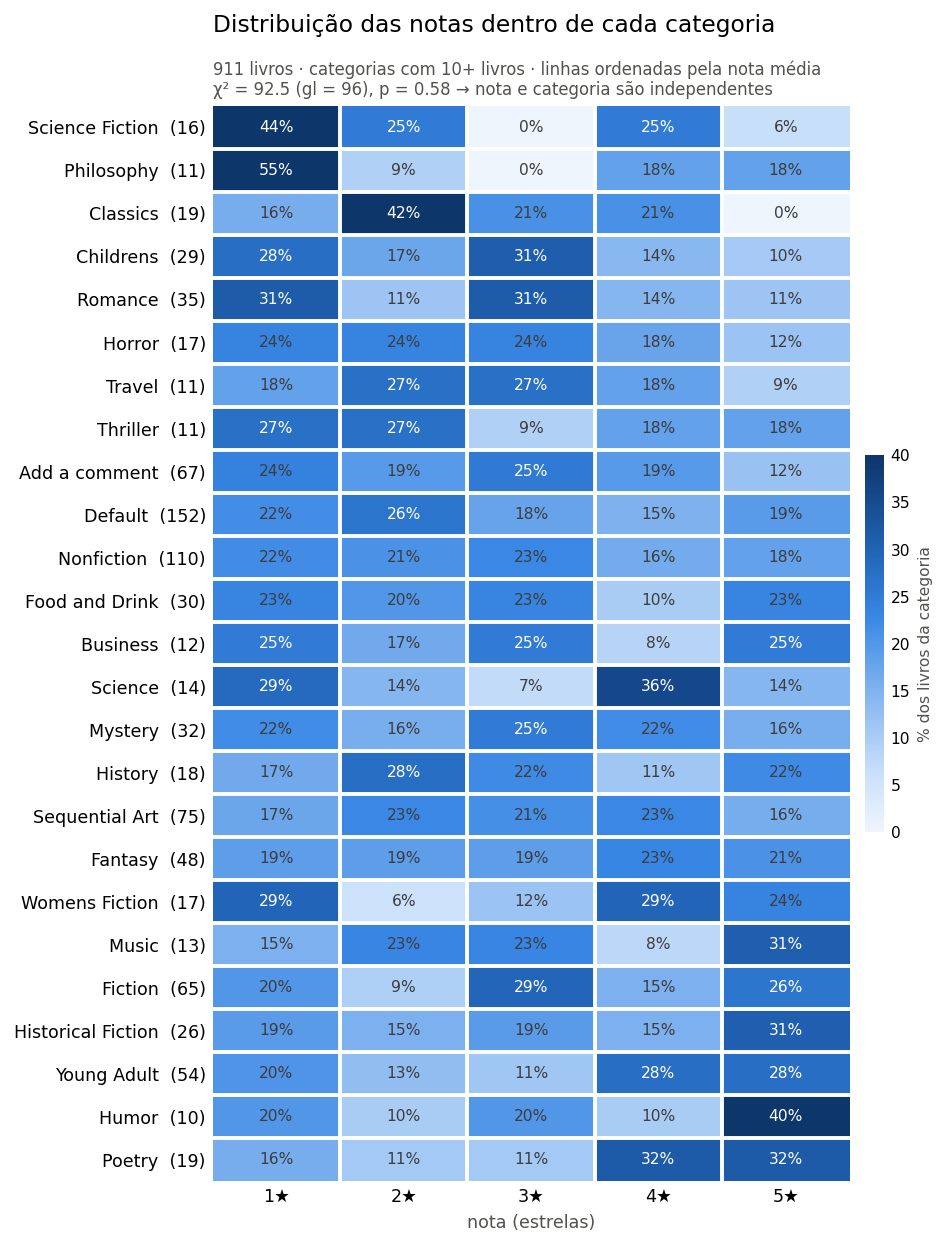

In [24]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

df_cat = pd.DataFrame(livros_cat)

# categorias com poucos livros nao permitem ler proporcao (varias tem 1 livro so),
# entao o mapa fica com as que tem pelo menos 10
MIN_LIVROS = 10
n_por_cat = df_cat["categoria"].value_counts()
grandes = n_por_cat[n_por_cat >= MIN_LIVROS].index
sub = df_cat[df_cat["categoria"].isin(grandes)]

contagem = pd.crosstab(sub["categoria"], sub["estrelas"])
ordem = sub.groupby("categoria")["estrelas"].mean().sort_values().index
contagem = contagem.loc[ordem]                                   # linha = categoria
pct = contagem.div(contagem.sum(axis=1), axis=0) * 100           # coluna = nota, em % da linha

# teste de independencia: qui-quadrado com p-valor por permutacao
def qui2(m):
    esp = m.sum(axis=1, keepdims=True) * m.sum(axis=0, keepdims=True) / m.sum()
    return ((m - esp) ** 2 / esp).sum()

obs = contagem.values.astype(float)
gl = (obs.shape[0] - 1) * (obs.shape[1] - 1)
cod_cat = pd.Categorical(sub["categoria"], categories=ordem).codes
cod_est = sub["estrelas"].values - 1
rng = np.random.default_rng(0)
nulo = np.array([
    qui2(np.bincount(cod_cat * 5 + rng.permutation(cod_est), minlength=len(ordem) * 5)
         .reshape(len(ordem), 5).astype(float))
    for _ in range(2000)
])
p_valor = (nulo >= qui2(obs)).mean()

# rampa sequencial de UM tom so (claro = pouco, escuro = muito)
azul = LinearSegmentedColormap.from_list("azul", [
    "#eef5fd", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5",
    "#256abf", "#184f95", "#0d366b"])

fig, ax = plt.subplots(figsize=(7.2, 9.0), dpi=140)
im = ax.imshow(pct.values, cmap=azul, aspect="auto", vmin=0, vmax=40)

ax.set_xticks(range(5), [f"{i}★" for i in pct.columns])
ax.set_yticks(range(len(pct)), [f"{c}  ({int(contagem.loc[c].sum())})" for c in pct.index])
ax.tick_params(length=0, labelsize=9)
for lado in ax.spines.values():
    lado.set_visible(False)

# respiro branco de 2px entre as celulas
ax.set_xticks([x - 0.5 for x in range(1, 5)], minor=True)
ax.set_yticks([y - 0.5 for y in range(1, len(pct))], minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", length=0)

for i in range(pct.shape[0]):
    for j in range(pct.shape[1]):
        v = pct.values[i, j]
        ax.text(j, i, f"{v:.0f}%", ha="center", va="center", fontsize=8,
                color="white" if v > 24 else "#3d3d3d")

ax.set_xlabel("nota (estrelas)", fontsize=9, color="#52514e")
ax.set_title("Distribuição das notas dentro de cada categoria", fontsize=12, loc="left", pad=38)
ax.text(0, 1.006,
        f"{len(sub)} livros · categorias com {MIN_LIVROS}+ livros · linhas ordenadas pela nota média\n"
        f"χ² = {qui2(obs):.1f} (gl = {gl}), p = {p_valor:.2f} → nota e categoria são independentes",
        transform=ax.transAxes, fontsize=8.5, color="#52514e", va="bottom")

cb = fig.colorbar(im, ax=ax, shrink=0.35, pad=0.02)
cb.set_label("% dos livros da categoria", fontsize=8, color="#52514e")
cb.outline.set_visible(False)
cb.ax.tick_params(length=0, labelsize=8)
fig.tight_layout()
plt.show()

In [25]:
# a mesma matriz em numeros, para conferir o que o mapa mostra
print("contagem de livros por categoria x nota:")
display(contagem)

resumo = pd.DataFrame({
    "livros": contagem.sum(axis=1),
    "nota_media": sub.groupby("categoria")["estrelas"].mean().loc[ordem].round(2),
})
print("\nmedia geral: %.2f estrelas" % df_cat["estrelas"].mean())
print("qui-quadrado = %.1f | p = %.2f (2000 permutacoes)" % (qui2(obs), p_valor))
print("p alto => a diferenca entre as categorias e compativel com puro acaso\n")
display(resumo)

contagem de livros por categoria x nota:


estrelas,1,2,3,4,5
categoria,,,,,
Science Fiction,7,4,0,4,1
Philosophy,6,1,0,2,2
Classics,3,8,4,4,0
Childrens,8,5,9,4,3
Romance,11,4,11,5,4
Horror,4,4,4,3,2
Travel,2,3,3,2,1
Thriller,3,3,1,2,2
Add a comment,16,13,17,13,8



media geral: 2.92 estrelas
qui-quadrado = 92.5 | p = 0.58 (2000 permutacoes)
p alto => a diferenca entre as categorias e compativel com puro acaso



,livros,nota_media
categoria,,
Science Fiction,16,2.25
Philosophy,11,2.36
Classics,19,2.47
Childrens,29,2.62
Romance,35,2.63
Horror,17,2.71
Travel,11,2.73
Thriller,11,2.73
Add a comment,67,2.76
